# 0. Helper functions

In [105]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import matplotlib.pyplot as plt
import matplotlib
import os, random
import numpy as np
import tensorflow as tf
import torch

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# matplotlib.rcParams.update({'font.size': 20})

# train SVM model using GridSearchCV
def train_svm(X_train, y_train):
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.05, 0.1, 0.2]
    }
    svr = SVR(kernel='rbf')
    grid_search = GridSearchCV(
        estimator=svr, param_grid=param_grid, cv=3,
        scoring='neg_mean_squared_error', verbose=2, n_jobs=-1
    )
    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()
    return grid_search.best_estimator_, end - start


# train Random Forest model using GridSearchCV
def train_rf(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [2, 3, 5, 10],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf': [5, 10, 20],
        'max_features': ['sqrt', 0.3]
    }

    rf = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=3,
        scoring='r2',
        verbose=2,
        n_jobs=-1
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()

    return grid_search.best_estimator_, end - start


# train HistGradientBoostingRegressor model using RandomizedSearchCV
def train_histgb(X_train, y_train):
    param_dist = {
        'learning_rate': uniform(0.01, 0.09),
        'max_iter': randint(50, 150),
        'max_depth': randint(2, 5),
        'min_samples_leaf': randint(20, 80),
        'l2_regularization': uniform(0.5, 2.5),
        'max_leaf_nodes': randint(5, 31)
    }
    model = HistGradientBoostingRegressor(early_stopping=True, random_state=42)
    grid_search = RandomizedSearchCV(
        estimator=model, param_distributions=param_dist, n_iter=20,
        scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=2, random_state=42
    )
    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()
    return grid_search.best_estimator_, end - start


# model evaluation function
def evaluate_model(model, X_train, y_train, X_test, y_test, time=None):
    if time is not None:
        print(f"\n⏱️ Training Time: {time:.2f} seconds")

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)

    test_mse = mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    print(f"📊 Train MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R2: {train_r2:.4f}")
    print(f"📊 Test  MSE: {test_mse:.4f}, MAE: {test_mae:.4f}, R2: {test_r2:.4f}\n")


# 1. Data preprocessing

This notebook explores how combining different molecular representations affects the quality of molecular property prediction. We start with loading a dataset of 4200 molecules consisting of SMILES notation of each molecule, and their lipohilicity values.

In [109]:
import deepchem as dc
import numpy as np
from sklearn.model_selection import train_test_split
from rdkit import Chem

tasks, datasets, transformers = dc.molnet.load_lipo(
    featurizer='ecfp',
    splitter='scaffold',   # splitter choice no longer matters -- we discard this grouping below
    reload=False
)

train, val, test = datasets
all_smiles = np.concatenate([train.ids, val.ids, test.ids], axis=0)
all_y = [v[0] for v in train.y] + [v[0] for v in val.y] + [v[0] for v in test.y]
all_smiles = [Chem.CanonSmiles(s) for s in all_smiles]

train_smiles, test_smiles, train_y, test_y = train_test_split(
    all_smiles, all_y, test_size=0.2, random_state=42
)

print("Training set sample size: ", len(train_smiles))
print("Test set sample size: ", len(test_smiles))

Training set sample size:  3360
Test set sample size:  840


In [110]:
import pandas as pd

data_train = pd.DataFrame({'smiles': train_smiles, 'lipo': train_y, 'train': [True for _ in range(len(train_smiles))]})
data_test = pd.DataFrame({'smiles': test_smiles, 'lipo': test_y, 'train': [False for _ in range(len(test_smiles))]})

data = pd.concat([data_train, data_test], ignore_index=True)

data.isna().sum()

smiles    0
lipo      0
train     0
dtype: int64

All molecules are successfully fetched.

In [112]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_mask = data['train'] == True
scaler.fit(np.array(data.loc[train_mask, 'lipo']).reshape(-1, 1))
data['lipo'] = scaler.transform(np.array(data['lipo']).reshape(-1, 1))
data.head()

,smiles,lipo,train
0,CC(C)c1ccc(Sc2cnc(O)c(C(=O)NCc3ccccc3)c2)cc1,0.866667,True
1,CCOC(=O)[C@H](Cc1ccc([N+](=O)[O-])cc1)NC(=O)c1...,0.715000,True
2,Cc1c(Cl)ccc(OC2CCN(CC3CCN([C@@H](Cc4ccc(F)cc4)...,0.775000,True
3,Nc1[nH]ncc1S(=O)(=O)c1ccccc1,0.433333,True
4,CC(=O)Nc1ccc(CNc2[nH]nc3cccc(Oc4ccc(S(C)(=O)=O...,0.688333,True


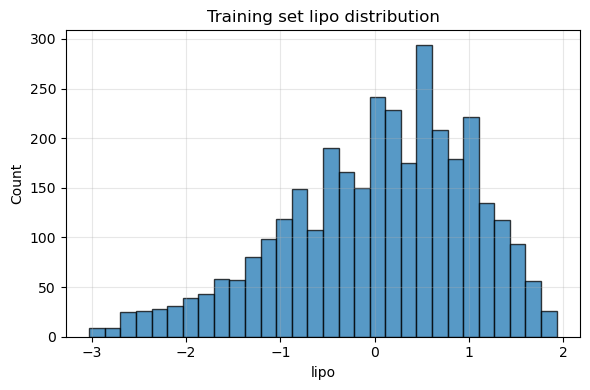

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data_train['lipo'], bins=30, edgecolor='black', alpha=0.75)
plt.xlabel('lipo')
plt.ylabel('Count')
plt.title('Training set lipo distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Molecular representations

## 2.1. Molecular descriptors

In [114]:
from rdkit.Chem import AllChem
from mordred import Calculator, descriptors
import tempfile
import os

def generate_3d_conformer(mol):
    """
    Generate 3D conformer for a molecule.
    """
    mol = Chem.AddHs(mol)
    success = AllChem.EmbedMolecule(mol, randomSeed=42, useRandomCoords=True)
    if success == -1:
        return None
    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except:
        try:
            AllChem.UFFOptimizeMolecule(mol)
        except:
            return None
    return mol

def smiles_to_sdf(df, smiles_col='smiles', id_col='ChEMBL_ID'):
    """
    Convert SMILES to SDF file with 3D conformers.
    """
    mols = []
    valid_indices = []

    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row[smiles_col])
        if mol is not None:
            mol_3d = generate_3d_conformer(mol)
            if mol_3d is not None:
                # Add properties to the molecule
                for col in df.columns:
                    if col != smiles_col:
                        mol_3d.SetProp(col, str(row[col]))
                mols.append(mol_3d)
                valid_indices.append(idx)
            else:
                print(f"Failed to generate 3D conformer for molecule {row[id_col]}")

    temp_sdf = tempfile.NamedTemporaryFile(suffix='.sdf', delete=False)
    writer = Chem.SDWriter(temp_sdf.name)

    for mol in mols:
        writer.write(mol)
    writer.close()

    return temp_sdf.name, valid_indices

def calculate_mordred_descriptors(sdf_file):
    """
    Calculate all Mordred descriptors including 3D.
    """
    calc = Calculator(descriptors, ignore_3D=False)
    mols = [mol for mol in Chem.SDMolSupplier(sdf_file) if mol is not None]
    df_descriptors = calc.pandas(mols)
    return df_descriptors

def generate_molecular_descriptors(data):
    print("Converting SMILES to 3D structures and generating SDF file...")
    sdf_file, valid_indices = smiles_to_sdf(df=data, id_col='smiles')

    try:
        print("Calculating descriptors...")
        descriptors_df = calculate_mordred_descriptors(sdf_file)

        # Combine the descriptors with the original data
        valid_data = data.iloc[valid_indices].reset_index(drop=True)
        final_dataset = pd.concat([valid_data.reset_index(drop=True), descriptors_df.reset_index(drop=True)], axis=1)

        # Save the complete dataset
        final_dataset.to_csv('molecular_features.csv', index=False)

        # Print summary statistics
        print("\nDataset Summary:")
        print(f"Total molecules processed: {len(final_dataset)}")
        print(f"Total features generated: {len(final_dataset.columns)}")

    finally:
        # Clean up temporary file
        os.remove(sdf_file)

    return final_dataset

In [115]:
data = generate_molecular_descriptors(data)

Converting SMILES to 3D structures and generating SDF file...
Calculating descriptors...


  1%|          | 52/4200 [00:04<03:10, 21.75it/s] 

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  9%|▊         | 365/4200 [00:18<02:20, 27.33it/s]

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 93%|█████████▎| 3906/4200 [02:00<00:10, 29.14it/s]

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 4200/4200 [02:10<00:00, 32.23it/s]



Dataset Summary:
Total molecules processed: 4200
Total features generated: 1829


In [116]:
from sklearn.feature_selection import VarianceThreshold

def prepare_features(descriptors_df):
    """
    Clean and prepare descriptors for machine learning while preserving specified columns.
    Fits NaN-column selection and VarianceThreshold on TRAIN rows only, then applies
    the identical transformation to every row -- avoids test rows influencing which
    columns get kept.
    """
    string_columns_to_preserve = ['smiles', 'train', 'lipo']
    preserved_columns = descriptors_df[string_columns_to_preserve]

    numeric_df = descriptors_df.drop(columns=string_columns_to_preserve, errors='ignore')
    numeric_df = numeric_df.apply(pd.to_numeric, errors='coerce')
    print("Number of descriptors before cleaning:", numeric_df.shape[1])

    train_mask = descriptors_df['train'] == True

    # which columns to keep -- decided from TRAIN rows only
    keep_cols = numeric_df.loc[train_mask].dropna(axis=1).columns
    numeric_df = numeric_df[keep_cols]
    print("Number of descriptors after removing NaN values (train-based):", numeric_df.shape[1])

    # a test molecule can still fail on a column every train molecule passed --
    # impute with the train median rather than leaving NaN or using test's own median
    train_medians = numeric_df.loc[train_mask].median()
    numeric_df = numeric_df.fillna(train_medians)

    # fit VarianceThreshold on TRAIN rows only, apply the SAME fitted selector to everything
    selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
    selection.fit(numeric_df.loc[train_mask])
    selected_columns = numeric_df.columns[selection.get_support()]

    numeric_df_array = selection.transform(numeric_df)
    numeric_df = pd.DataFrame(numeric_df_array, columns=selected_columns, index=descriptors_df.index)

    final_df = pd.concat([preserved_columns.reset_index(drop=True), numeric_df.reset_index(drop=True)], axis=1)
    print("Number of descriptors after cleaning:", final_df.shape[1])

    return final_df

In [117]:
data_prepared = prepare_features(data)

Number of descriptors before cleaning: 1826
Number of descriptors after removing NaN values (train-based): 1005
Number of descriptors after cleaning: 513


In [118]:
data = data_prepared.copy()

Prije samog odabira značajki, skup podataka odvaja se na skup za treniranje i skup za testiranje, s obzirom na to da modeli koji se koriste u nastavku ove bilježnice zahtijevaju treniranje. Skup za treniranje koristi se za treniranje modela za redukciju dimenzionalnosti te, kasnije, prediktivnih modela, a skup za testiranje koristi se za predstavljanje performansi i mogućnosti generalizacije prediktivnih modela.

In [119]:
from sklearn.model_selection import train_test_split

data_train = data[data['train'] == True]
data_test = data[data['train'] == False]

data_train = data_train.drop(columns=['train'])
data_test = data_test.drop(columns=['train'])

len(data_train), len(data_test)

(3360, 840)

Proces odabira molekularnih deskriptora podrazumijeva je nekoliko koraka:
1. Uklanjanje autokorelacijskih deskriptora koji su često redundantni i slabije interpretabilni
2. Skaliranje vrijednosti molekularnih deskriptora na raspon između 0 i 1
3. Procjena važnosti značajki pomoću algoritma slučajne šume
4. Uklanjanje visoko koreliranih značajki korištenjem Pearsonova koeficijenta - pronalaze su svi parovi molekularnih deskriptora s vrijednošću earsonova koeficijenta većom od 0.9 te se uklanja deskriptor s manjom važnošću
5. Primjena rekurzivnog uklanjanja značajki s unakrsnom validacijom (RFECV) - nadzirana metoda odabira značajki koja odabire optimalan broj značajki na temelju koeficijenta determinacije

Odabir značajki provodi se na skupovima za testiranje.

In [120]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV

def efficient_feature_selection(X: pd.DataFrame,
                                y: pd.Series,
                                min_features: int = 20,
                                max_features: int = 30,
                                random_state: int = 42,
                                scale = True):
    """
    Efficient feature selection using a two-step approach:
    1. Remove autocorrelation descriptors
    2. Initial feature reduction using RandomForest importance
    3. Fine-tuning using RFECV with reduced feature set
    4. Post-processing to remove one of two highly correlated features.

    Args:
        X: Feature DataFrame
        y: Target Series
        min_features: Minimum number of features to select
        max_features: Maximum number of features for initial filtering
        random_state: Random seed for reproducibility

    Returns:
        Tuple of (selected features DataFrame, list of feature names)
    """
    orig_num = len(X.columns)

    # Step 0: Remove autocorrelation descriptors
    autocorr_keywords = ["ATSC", "AATS"]  # Keywords to identify autocorrelation descriptors
    autocorr_features = [
        col for col in X.columns if any(keyword in col for keyword in autocorr_keywords)
    ]
    X = X.drop(columns=autocorr_features)

    print(f"Removed {len(autocorr_features)} autocorrelation descriptors.")

    # Step 1: Scale the features
    if scale:
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X.to_numpy())
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    else:
        X_scaled = X.copy()

    # Step 2: Initial feature reduction using RandomForest importance
    pre_selector = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        n_jobs=-1,
        random_state=random_state
    )

    pre_selector.fit(X_scaled, y)

    # Get feature importance and select top features
    importances = pd.Series(pre_selector.feature_importances_, index=X.columns)
    importances_sorted = importances.sort_values(ascending=False)

    # Select top features (max_features or 2 * target_features, whichever is smaller)
    n_features_to_keep = min(max_features, len(importances_sorted))
    top_features = importances_sorted.head(n_features_to_keep).index.tolist()

    # Step 3: Filter to top features
    X_reduced = X_scaled[top_features]

    # Step 4: Post-processing - Remove highly correlated features
    # Calculate Pearson correlation
    corr_matrix = X_reduced.corr(method='pearson').abs()
    upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1)
    upper_corr_matrix = pd.DataFrame(corr_matrix.values * upper_triangle,
                                     columns=corr_matrix.columns,
                                     index=corr_matrix.index)

    # Identify pairs of highly correlated features
    high_corr_pairs = [(col1, col2)
                       for col1 in upper_corr_matrix.columns
                       for col2 in upper_corr_matrix.index
                       if upper_corr_matrix.loc[col2, col1] > 0.9]  # Threshold for correlation

    # Remove the feature with the smaller importance from each pair
    features_to_remove = set()
    for feat1, feat2 in high_corr_pairs:
        if feat1 in importances and feat2 in importances:
            # Compare importance and remove the less important feature
            if importances[feat1] > importances[feat2]:
                features_to_remove.add(feat2)
            else:
                features_to_remove.add(feat1)

    # Remove highly correlated features
    X_reduced = X_reduced.drop(columns=list(features_to_remove))
    top_features = [feat for feat in top_features if feat not in features_to_remove]

    # Step 5: RFECV on reduced feature set
    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=random_state
    )

    rfecv = RFECV(
        estimator=rf_model,
        step=1,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        min_features_to_select=min_features,
        verbose=0
    )

    rfecv.fit(X_reduced, y)

    # Get final selected features
    final_features = X_reduced.columns[rfecv.support_].tolist()

    # Calculate final feature importance
    final_importance = pd.Series(
        rfecv.estimator_.feature_importances_,
        index=final_features
    ).sort_values(ascending=False)

    print(f'Number of features reduced from {orig_num} to {len(final_features)}.')

    return X[final_features], final_features, final_importance

def plot_importance(selected_features, final_importance):
    # final_importance_scaled = (final_importance - min(final_importance)) / (max(final_importance) - min(final_importance))
    importances_rfe = dict(zip(selected_features, final_importance))
    plt.barh(selected_features, final_importance)
    plt.show()
    print(importances_rfe)

In [121]:
X_descriptors_train = data_train.drop(columns=['lipo', 'smiles']).copy()
X_descriptors_test = data_test.drop(columns=['lipo', 'smiles']).copy()

y_train = np.array(data_train['lipo'])
y_test = np.array(data_test['lipo'])

In [122]:
logp_like_cols = [c for c in X_descriptors_train.columns if c == 'SLogP']
print("Dropping near-target descriptor(s):", logp_like_cols)

X_descriptors_train = X_descriptors_train.drop(columns=logp_like_cols)
X_descriptors_test = X_descriptors_test.drop(columns=logp_like_cols)

Dropping near-target descriptor(s): ['SLogP']


Removed 143 autocorrelation descriptors.
Number of features reduced from 509 to 28.


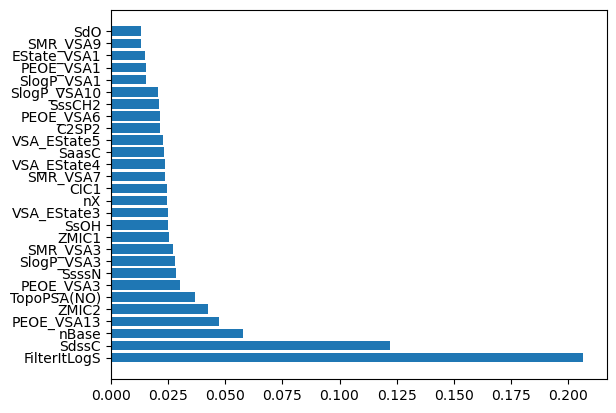

{'FilterItLogS': 0.20670017004166305, 'SdssC': 0.1221686315476882, 'nBase': 0.057624259152072706, 'PEOE_VSA13': 0.04719631447019895, 'ZMIC2': 0.042257410089755594, 'TopoPSA(NO)': 0.036770962858808084, 'PEOE_VSA3': 0.030151696184034786, 'SsssN': 0.028251880448518285, 'SlogP_VSA3': 0.027975776726853776, 'SMR_VSA3': 0.026989448167426662, 'ZMIC1': 0.025235010565725642, 'SsOH': 0.024886492017253372, 'VSA_EState3': 0.02484600840563111, 'nX': 0.024669191652224576, 'CIC1': 0.024381684639858826, 'SMR_VSA7': 0.023686184172616965, 'VSA_EState4': 0.023518788244287363, 'SaasC': 0.023169188638287232, 'VSA_EState5': 0.022821323275102046, 'C2SP2': 0.021621038122185444, 'PEOE_VSA6': 0.02126594704462108, 'SssCH2': 0.020832404477498397, 'SlogP_VSA10': 0.020740481623885143, 'SlogP_VSA1': 0.01542655016183393, 'PEOE_VSA1': 0.015231412398614825, 'EState_VSA1': 0.014979203022883313, 'SMR_VSA9': 0.013317341491017147, 'SdO': 0.013285200359453537}


In [123]:
X_selected_descriptors, selected_features_descriptors, final_importance_descriptors = efficient_feature_selection(
    X = X_descriptors_train,
    y = y_train,
    min_features = 20,
    max_features = 30
)

plot_importance(selected_features_descriptors, final_importance_descriptors)

In [124]:
X_descriptors_train = X_selected_descriptors.copy()
X_descriptors_test = X_descriptors_test[X_selected_descriptors.columns]

143 autocorrelation descriptors were removed. After RFECV selection, 28 descriptors remain.

## 2.2. Molecular fingerprints

In [125]:
from rdkit.Chem.Pharm2D import Generate
from rdkit.Chem.Pharm2D import Gobbi_Pharm2D
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import rdFingerprintGenerator

# Morgan
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)
data_train['morgan'] = data_train['smiles'].apply(
    lambda x: np.array(list(morgan_gen.GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()), dtype=int))
data_test['morgan'] = data_test['smiles'].apply(
    lambda x: np.array(list(morgan_gen.GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()), dtype=int))

# ErG (2D Pharmacophore / Scaffold hopping)
factory = Gobbi_Pharm2D.factory
def erg_to_numpy(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = Generate.Gen2DFingerprint(mol, factory)
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    ConvertToNumpyArray(fp, arr)
    return arr
data_train['erg'] = data_train['smiles'].apply(
    lambda x: Generate.Gen2DFingerprint(Chem.MolFromSmiles(x), factory))
data_test['erg'] = data_test['smiles'].apply(
    lambda x: Generate.Gen2DFingerprint(Chem.MolFromSmiles(x), factory))

In [128]:
print("ECFP dimensionality: ", len(data_train['morgan'].tolist()[0]))
print("ErG dimensionality: ", len(data_train['erg'].tolist()[0]))

ECFP dimensionality:  512
ErG dimensionality:  39972


In [129]:
from sklearn.decomposition import TruncatedSVD

def reduce_fp(X_train, X_test, n_components=64):
    selector = VarianceThreshold(threshold=0.001)
    X_var_train = selector.fit_transform(X_train)
    X_var_test = selector.transform(X_test)
    print(f"After variance thresholding: {X_var_test.shape}")

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_reduced_train = svd.fit_transform(X_var_train)
    X_reduced_test = svd.transform(X_var_test)

    print(f"After TruncatedSVD({n_components}): {X_reduced_train.shape}, "
          f"variance retained: {svd.explained_variance_ratio_.sum():.3f}")
    return X_reduced_train, X_reduced_test

X_ecfp_train, X_ecfp_test = reduce_fp(np.array(data_train['morgan'].tolist()), np.array(data_test['morgan'].tolist()), n_components=128)
X_erg_train, X_erg_test = reduce_fp(np.array(data_train['erg'].tolist()), np.array(data_test['erg'].tolist()), n_components=128)

After variance thresholding: (840, 512)
After TruncatedSVD(128): (3360, 128), variance retained: 0.721
After variance thresholding: (840, 10799)
After TruncatedSVD(128): (3360, 128), variance retained: 0.683


## 2.3. Mol2Vec

In [130]:
from tqdm import tqdm

def sentences2vec(sentences, model, unseen='UNK'):
    """
    Convert a list of sentences (molecular substructure tokens) into vector representations
    using a gensim Word2Vec model (Gensim 4.x compatible).

    Parameters:
    - sentences: list of lists of substructure tokens (e.g., [['[C@@H]', '[CH3]'], ...])
    - model: gensim Word2Vec model (must be trained or preloaded)
    - unseen: token to use for unseen words (default 'UNK')

    Returns:
    - list of numpy arrays (each array = vector for one molecule)
    """
    vectors = []
    for sentence in tqdm(sentences, desc="Embedding molecules"):
        vecs = []
        for word in sentence:
            if word in model.wv:
                vecs.append(model.wv[word])
            elif unseen in model.wv:
                vecs.append(model.wv[unseen])
        if vecs:
            vectors.append(np.mean(vecs, axis=0))
        else:
            # In case no known words in sentence, use zero vector
            vectors.append(np.zeros(model.vector_size))
    return vectors


In [131]:
import gensim
from mol2vec.features import mol2alt_sentence
# from tqdm import tqdm
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Load model
model = gensim.models.Word2Vec.load("models/model_300dim.pkl")
sentences_train = [mol2alt_sentence(Chem.MolFromSmiles(smi), radius=1) for smi in data_train['smiles'].tolist()]
sentences_test = [mol2alt_sentence(Chem.MolFromSmiles(smi), radius=1) for smi in data_test['smiles'].tolist()]

# Convert to vectors
vectors_train = sentences2vec(sentences_train, model)
vectors_test = sentences2vec(sentences_test, model)
data_train['mol2vec'] = vectors_train
data_test['mol2vec'] = vectors_test

Embedding molecules: 100%|██████████| 840/840 [00:00<00:00, 2292.79it/s]


In [132]:
print("Mol2Vec embeddings dimensionality: ", len(data_train['mol2vec'].tolist()[0]))

Mol2Vec embeddings dimensionality:  300


Kako bi se olakšalo kasnije treniranje i usporedba prediktivnih modela, primijenjena je redukcija s 300 na 128 dimenzionalnosti korištenjem autoenkodera.

Autoenkoder se u ovom slučaju sastoji se od ulaznog sloja, jednog gustog sloja koji služi kao enkoder, te drugog gustog sloja koji služi kao dekoder Model je treniran tijekom 50 epoha na skupovima za treniranje, na podskupovima od 32 molekule. 

In [133]:
from tensorflow.keras import layers, models
import tensorflow as tf

def reduce_embedding_dim(X_train, X_test, encoding_dim=128, seed=42):
    tf.random.set_seed(seed)

    input_dim = X_train.shape[1]

    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim, activation='relu',
                            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(input_layer)
    decoded = layers.Dense(input_dim, activation='linear',
                            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(encoded)

    autoencoder = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, encoded)

    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True)

    X_reduced_train = encoder.predict(X_train)
    X_reduced_test = encoder.predict(X_test)

    return X_reduced_train, X_reduced_test

In [134]:
def reconstruction_quality(X_train, encoding_dim, seed=42):
    tf.random.set_seed(seed)
    input_dim = X_train.shape[1]
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim, activation='relu',
                            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(input_layer)
    decoded = layers.Dense(input_dim, activation='linear',
                            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(encoded)
    autoencoder = models.Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True, verbose=0)

    final_mse = history.history['loss'][-1]
    pseudo_r2 = 1 - final_mse / np.var(X_train)
    print(f"encoding_dim={encoding_dim}: final MSE={final_mse:.4f}, pseudo-R²={pseudo_r2:.3f}")
    return pseudo_r2

X_mol2vec_train_arr = np.array([emb for emb in data_train['mol2vec']])
reconstruction_quality(X_mol2vec_train_arr, 64)
reconstruction_quality(X_mol2vec_train_arr, 128)




encoding_dim=64: final MSE=0.0002, pseudo-R²=0.985
encoding_dim=128: final MSE=0.0001, pseudo-R²=0.991


0.990818394594647

In [135]:
X_mol2vec_train, X_mol2vec_test = reduce_embedding_dim(
    np.array([emb for emb in data_train['mol2vec']]),
    np.array([emb for emb in data_test['mol2vec']]),
    encoding_dim=64)

print("\nMol2Vec embeddings dimensionality after reduction: ", X_mol2vec_train.shape[1])

Epoch 1/50
105/105 [==============================] - 1s 8ms/step - loss: 0.0029
Epoch 2/50
105/105 [==============================] - 1s 8ms/step - loss: 8.9701e-04
Epoch 3/50
105/105 [==============================] - 1s 7ms/step - loss: 7.3274e-04
Epoch 4/50
105/105 [==============================] - 1s 8ms/step - loss: 6.2942e-04
Epoch 5/50
105/105 [==============================] - 1s 7ms/step - loss: 5.3626e-04
Epoch 6/50
105/105 [==============================] - 1s 7ms/step - loss: 4.7911e-04
Epoch 7/50
105/105 [==============================] - 1s 7ms/step - loss: 4.3837e-04
Epoch 8/50
105/105 [==============================] - 1s 7ms/step - loss: 4.0713e-04
Epoch 9/50
105/105 [==============================] - 1s 7ms/step - loss: 3.7995e-04
Epoch 10/50
105/105 [==============================] - 1s 8ms/step - loss: 3.5758e-04
Epoch 11/50
105/105 [==============================] - 1s 7ms/step - loss: 3.4157e-04
Epoch 12/50
105/105 [==============================] - 1s 8ms/step 

## 2.4. ChemBERTa

Generiranje druge vrste latentnih reprezentacija, korištenjem ChemBERTe, nešto je složeniji i vremenski zahtjevniji proces. I ovaj je model unaprijed treniran na velikom broju molekula, no ovdje se dodatno trenira na skupu za treniranje predikcije potentosti. Treniranje se provodi tijekom 20 epoha korištenjem trostruke unakrsne validacije, pri čemu se kao optimizator koristi Adam algoritam sa stopom učenja 10−5. Nakon dodatnog podešavanja, model se koristi za generiranje latentnih reprezentacija molekula u skupu za testiranje.

In [136]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
import torch.nn as nn
from torch.utils.data import Dataset
import torch

model_name = "seyonec/ChemBERTa-zinc-base-v1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(smiles):
    return tokenizer(smiles, padding=True, truncation=True, return_tensors='pt')

class SMILESDataset(Dataset):
    def __init__(self, smiles_list, targets):
        self.inputs = tokenizer(smiles_list, padding=True, truncation=True, return_tensors='pt')
        self.targets = torch.tensor(targets).float().unsqueeze(1)
    
    def __len__(self):
        return len(self.targets)
    
    def __getitem__(self, idx):
        return (
            self.inputs['input_ids'][idx],
            self.inputs['attention_mask'][idx],
            self.targets[idx]
        )
    
class ChemBERTaRegressor(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.chemberta = AutoModel.from_pretrained(model_name)
        self.regressor = nn.Linear(self.chemberta.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.chemberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.regressor(pooled_output), pooled_output  # return both prediction and embedding


def train_model(model, dataloader, optimizer, device):
    model.train()
    for input_ids, attn_mask, targets in dataloader:
        input_ids, attn_mask, targets = input_ids.to(device), attn_mask.to(device), targets.to(device)
        preds, _ = model(input_ids, attn_mask)
        loss = nn.MSELoss()(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [137]:
from sklearn.model_selection import KFold
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

smiles_list = data_train['smiles'].tolist()
targets = data_train['lipo'].tolist()

# kept for the downstream embedding-extraction cell, which still expects X/attention
inputs = tokenize(smiles_list)
X = inputs['input_ids']
attention = inputs['attention_mask']
y = torch.tensor(targets).float().unsqueeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_EPOCHS = 20
N_SPLITS = 3
SEED = 42
torch.manual_seed(SEED)

# --- Phase 1: K-fold CV, purely to get an honest validation estimate of the fine-tuning recipe.
# Fresh model per fold is fine here -- disposable, only the val MSE matters.
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_mse_list = []

for fold, (train_idx, val_idx) in enumerate(kf.split(smiles_list)):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")

    train_smiles = [smiles_list[i] for i in train_idx]
    val_smiles   = [smiles_list[i] for i in val_idx]
    train_targets = y[train_idx]
    val_targets   = y[val_idx]

    train_dataset = SMILESDataset(train_smiles, train_targets)
    val_dataset   = SMILESDataset(val_smiles, val_targets)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                               generator=torch.Generator().manual_seed(SEED))
    val_loader   = DataLoader(val_dataset, batch_size=32)

    fold_model = ChemBERTaRegressor(model_name).to(device)
    optimizer  = Adam(fold_model.parameters(), lr=2e-5)

    for epoch in range(N_EPOCHS):
        train_model(fold_model, train_loader, optimizer, device)

    fold_model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for input_ids, attn_mask, val_y in val_loader:
            input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
            preds, _ = fold_model(input_ids, attn_mask)
            all_preds.append(preds.cpu())
            all_targets.append(val_y)

    preds_cat = torch.cat(all_preds).squeeze()
    targets_cat = torch.cat(all_targets).squeeze()
    mse = nn.MSELoss()(preds_cat, targets_cat)
    fold_mse_list.append(mse.item())
    print(f"Fold {fold+1} MSE: {mse.item():.4f}")

print(f"\n✅ CV MSE (mean across {N_SPLITS} folds, {N_EPOCHS}-epoch fine-tune each): {sum(fold_mse_list)/N_SPLITS:.4f}")

# --- Phase 2: fine-tune ONE final model on the FULL training set for N_EPOCHS.
# This is the model actually used downstream for embedding extraction.
full_dataset = SMILESDataset(smiles_list, y)
full_loader = DataLoader(full_dataset, batch_size=16, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))

model = ChemBERTaRegressor(model_name).to(device)
optimizer = Adam(model.parameters(), lr=2e-5)

for epoch in range(N_EPOCHS):
    train_model(model, full_loader, optimizer, device)
    print(f"Final fine-tune epoch {epoch+1}/{N_EPOCHS} done")


--- Fold 1/3 ---


C:\Users\afs\AppData\Local\Temp\ipykernel_7448\3240592466.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.targets = torch.tensor(targets).float().unsqueeze(1)
c:\Users\afs\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Fold 1 MSE: 0.0435

--- Fold 2/3 ---
Fold 2 MSE: 0.0449

--- Fold 3/3 ---
Fold 3 MSE: 0.0403

✅ CV MSE (mean across 3 folds, 20-epoch fine-tune each): 0.0429
Final fine-tune epoch 1/20 done
Final fine-tune epoch 2/20 done
Final fine-tune epoch 3/20 done
Final fine-tune epoch 4/20 done
Final fine-tune epoch 5/20 done
Final fine-tune epoch 6/20 done
Final fine-tune epoch 7/20 done
Final fine-tune epoch 8/20 done
Final fine-tune epoch 9/20 done
Final fine-tune epoch 10/20 done
Final fine-tune epoch 11/20 done
Final fine-tune epoch 12/20 done
Final fine-tune epoch 13/20 done
Final fine-tune epoch 14/20 done
Final fine-tune epoch 15/20 done
Final fine-tune epoch 16/20 done
Final fine-tune epoch 17/20 done
Final fine-tune epoch 18/20 done
Final fine-tune epoch 19/20 done
Final fine-tune epoch 20/20 done


In [138]:
from torch.utils.data import DataLoader, TensorDataset

train_embed_dataset = TensorDataset(X, attention)
train_embed_loader = DataLoader(train_embed_dataset, batch_size=32)

model.eval()
all_embeddings = []

with torch.no_grad():
    for input_ids, attn_mask in train_embed_loader:
        input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
        _, embeddings = model(input_ids, attn_mask)
        all_embeddings.append(embeddings.cpu())

embeddings_train = torch.cat(all_embeddings).numpy()

data_train['embedding'] = [emb for emb in embeddings_train]

In [140]:
from torch.utils.data import DataLoader, TensorDataset

inputs_test = tokenize(data_test['smiles'].tolist())
X_test = inputs_test['input_ids']
attention_test = inputs_test['attention_mask']
y_test = torch.tensor(data_test['lipo'].tolist()).float().unsqueeze(1)


test_embed_dataset = TensorDataset(X_test, attention_test)
test_embed_loader = DataLoader(test_embed_dataset, batch_size=32)

model.eval()
all_embeddings = []

with torch.no_grad():
    for input_ids, attn_mask in test_embed_loader:
        input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
        _, embeddings = model(input_ids, attn_mask)
        all_embeddings.append(embeddings.cpu())

embeddings_test = torch.cat(all_embeddings).numpy()

data_test['embedding'] = [emb for emb in embeddings_test]

In [141]:
torch.save(model, './models/chemberta_v3.pt')

In [142]:
len(data_train['embedding'].tolist()[0])

768

In [143]:
X_chemberta_train_arr = np.array([emb for emb in data_train['embedding']])
reconstruction_quality(X_chemberta_train_arr, 64)
reconstruction_quality(X_chemberta_train_arr, 128)

encoding_dim=64: final MSE=0.0015, pseudo-R²=0.998
encoding_dim=128: final MSE=0.0010, pseudo-R²=0.999


0.9989497943574566

In [144]:
X_chemberta_train, X_chemberta_test = reduce_embedding_dim(
    np.array([emb for emb in data_train['embedding']]),
    np.array([emb for emb in data_test['embedding']]),
    encoding_dim=64)

Epoch 1/50
105/105 [==============================] - 1s 4ms/step - loss: 0.1920
Epoch 2/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0037
Epoch 3/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0037
Epoch 4/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0037
Epoch 5/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0037
Epoch 6/50
105/105 [==============================] - 0s 3ms/step - loss: 0.0037
Epoch 7/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0036
Epoch 8/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0036
Epoch 9/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0036
Epoch 10/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0035
Epoch 11/50
105/105 [==============================] - 0s 3ms/step - loss: 0.0035
Epoch 12/50
105/105 [==============================] - 0s 4ms/step - loss: 0.0034
Epoch 13/50
105/105 [====

In [145]:
import pickle, os

os.makedirs("./data", exist_ok=True)
RECOMPUTE = True  # set to False only after verifying the fixed lipo pipeline end-to-end once

train_vars = {
    "X_descriptors_train": X_descriptors_train,
    "X_ecfp_train": X_ecfp_train,
    "X_erg_train": X_erg_train,
    "X_mol2vec_train": X_mol2vec_train,
    "X_chemberta_train": X_chemberta_train,
    "data_train": data_train,
}
test_vars = {
    "X_descriptors_test": X_descriptors_test,
    "X_ecfp_test": X_ecfp_test,
    "X_erg_test": X_erg_test,
    "X_mol2vec_test": X_mol2vec_test,
    "X_chemberta_test": X_chemberta_test,
    "data_test": data_test,
}

if RECOMPUTE:
    for name, val in {**train_vars, **test_vars}.items():
        with open(f"./data/{name}_lipo_v2.pkl", "wb") as f:
            pickle.dump(val, f)
else:
    for name in {**train_vars, **test_vars}:
        with open(f"./data/{name}_lipo_v2.pkl", "rb") as f:
            globals()[name] = pickle.load(f)

# 3. Molecular Property Prediction

In [146]:
from sklearn.preprocessing import StandardScaler

scaler_desc = StandardScaler()
X_descriptors_train = scaler_desc.fit_transform(X_descriptors_train.values)
X_descriptors_test  = scaler_desc.transform(X_descriptors_test.values)

scaler_ecfp = StandardScaler()
X_ecfp_train = scaler_ecfp.fit_transform(X_ecfp_train)
X_ecfp_test  = scaler_ecfp.transform(X_ecfp_test)

scaler_erg = StandardScaler()
X_erg_train = scaler_erg.fit_transform(X_erg_train)
X_erg_test  = scaler_erg.transform(X_erg_test)

scaler_mol2vec = StandardScaler()
X_mol2vec_train = scaler_mol2vec.fit_transform(X_mol2vec_train)
X_mol2vec_test  = scaler_mol2vec.transform(X_mol2vec_test)

scaler_chemberta = StandardScaler()
X_chemberta_train = scaler_chemberta.fit_transform(X_chemberta_train)
X_chemberta_test  = scaler_chemberta.transform(X_chemberta_test)

In [147]:
import numpy as np

X_combined_train = np.hstack([
    X_descriptors_train,
    X_ecfp_train,
    X_erg_train,
    X_mol2vec_train,
    X_chemberta_train
])

y_train = np.array(data_train['lipo'])

X_combined_test = np.hstack([
    X_descriptors_test,
    X_ecfp_test,
    X_erg_test,
    X_mol2vec_test,
    X_chemberta_test
])

y_test = np.array(data_test['lipo'])

## 3.1. RF

In [149]:
# molekularni deskriptori
print('Molekularni deskriptori')
rf_descriptors, rf_descriptors_time = train_rf(X_descriptors_train, y_train)
evaluate_model(rf_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, rf_descriptors_time)

# molekularni otisci - ECFP
print('Molekularni otisci - ECFP')
rf_ecfp, rf_ecfp_time = train_rf(X_ecfp_train, y_train)
evaluate_model(rf_ecfp, X_ecfp_train, y_train, X_ecfp_test, y_test, rf_ecfp_time)

# molekularni otisci - ErG
print('Molekularni otisci - ErG')
rf_erg, rf_erg_time = train_rf(X_erg_train, y_train)
evaluate_model(rf_erg, X_erg_train, y_train, X_erg_test, y_test, rf_erg_time)

# mol2vec
print('Mol2Vec')
rf_mol2vec, rf_mol2vec_time = train_rf(X_mol2vec_train, y_train)
evaluate_model(rf_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, rf_mol2vec_time)

# chemberta
print('Chemberta')
rf_chemberta, rf_chemberta_time = train_rf(X_chemberta_train, y_train)
evaluate_model(rf_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, rf_chemberta_time)

Molekularni deskriptori
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 21.11 seconds
📊 Train MSE: 0.0095, MAE: 0.0761, R2: 0.7660
📊 Test  MSE: 0.0164, MAE: 0.0991, R2: 0.5787

Molekularni otisci - ECFP
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 73.35 seconds
📊 Train MSE: 0.0155, MAE: 0.0979, R2: 0.6171
📊 Test  MSE: 0.0275, MAE: 0.1294, R2: 0.2936

Molekularni otisci - ErG
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 70.83 seconds
📊 Train MSE: 0.0104, MAE: 0.0792, R2: 0.7426
📊 Test  MSE: 0.0227, MAE: 0.1164, R2: 0.4166

Mol2Vec
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 37.47 seconds
📊 Train MSE: 0.0149, MAE: 0.0974, R2: 0.6323
📊 Test  MSE: 0.0260, MAE: 0.1264, R2: 0.3305

Chemberta
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 21.85 seconds
📊 Train MSE: 0.0174, MAE: 0.1055, R2: 0.5695
📊 Test  MSE: 0.028

In [150]:
# kombinacija
print('Kombinirane molekularne reprezentacije')
rf_combined, rf_combined_time = train_rf(X_combined_train, y_train)
evaluate_model(rf_combined, X_combined_train, y_train, X_combined_test, y_test, rf_combined_time)

Kombinirane molekularne reprezentacije
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 183.58 seconds
📊 Train MSE: 0.0073, MAE: 0.0671, R2: 0.8205
📊 Test  MSE: 0.0175, MAE: 0.1022, R2: 0.5498



In [151]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge

# out-of-fold predictions for meta-model training only — avoids fitting Ridge on optimistic in-sample predictions
oof_descriptors = cross_val_predict(RandomForestRegressor(**rf_descriptors.get_params()), X_descriptors_train, y_train, cv=5, n_jobs=-1)
oof_ecfp        = cross_val_predict(RandomForestRegressor(**rf_ecfp.get_params()), X_ecfp_train, y_train, cv=5, n_jobs=-1)
oof_erg         = cross_val_predict(RandomForestRegressor(**rf_erg.get_params()), X_erg_train, y_train, cv=5, n_jobs=-1)
oof_mol2vec     = cross_val_predict(RandomForestRegressor(**rf_mol2vec.get_params()), X_mol2vec_train, y_train, cv=5, n_jobs=-1)
oof_chemberta   = cross_val_predict(RandomForestRegressor(**rf_chemberta.get_params()), X_chemberta_train, y_train, cv=5, n_jobs=-1)

meta_X = np.vstack((oof_descriptors, oof_ecfp, oof_erg, oof_mol2vec, oof_chemberta)).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

# test side unchanged in spirit — base models already trained on full X_train, so this part was never leaky
meta_test = np.vstack((
    rf_descriptors.predict(X_descriptors_test),
    rf_ecfp.predict(X_ecfp_test),
    rf_erg.predict(X_erg_test),
    rf_mol2vec.predict(X_mol2vec_test),
    rf_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Ansambl')
print(f'Training RMSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test RMSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')

Ansambl
Training RMSE: 0.0153, MAE: 0.0953, R2: 0.6231
Test RMSE: 0.0152, MAE: 0.0956, R2: 0.6099


## 3.1. SVM

In [152]:
# molekularni deskriptori
print('Molekularni deskriptori')
svm_descriptors, svm_descriptors_time = train_svm(X_descriptors_train, y_train)
evaluate_model(svm_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, svm_descriptors_time)

# molekularni otisci - ECFP
print('Molekularni otisci - ECFP')
svm_ecfp, svm_ecfp_time = train_svm(X_ecfp_train, y_train)
evaluate_model(svm_ecfp, X_ecfp_train, y_train, X_ecfp_test, y_test, svm_ecfp_time)

# molekularni otisci - ErG
print('Molekularni otisci - ErG')
svm_erg, svm_erg_time = train_svm(X_erg_train, y_train)
evaluate_model(svm_erg, X_erg_train, y_train, X_erg_test, y_test, svm_erg_time)

# mol2vec
print('Mol2Vec')
svm_mol2vec, svm_mol2vec_time = train_svm(X_mol2vec_train, y_train)
evaluate_model(svm_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, svm_mol2vec_time)

# chemberta
print('Chemberta')
svm_chemberta, svm_chemberta_time = train_svm(X_chemberta_train, y_train)
evaluate_model(svm_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, svm_chemberta_time)

Molekularni deskriptori
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 9.29 seconds
📊 Train MSE: 0.0052, MAE: 0.0550, R2: 0.8714
📊 Test  MSE: 0.0136, MAE: 0.0843, R2: 0.6501

Molekularni otisci - ECFP
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 20.54 seconds
📊 Train MSE: 0.0006, MAE: 0.0131, R2: 0.9851
📊 Test  MSE: 0.0186, MAE: 0.1007, R2: 0.5210

Molekularni otisci - ErG
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 20.56 seconds
📊 Train MSE: 0.0055, MAE: 0.0381, R2: 0.8651
📊 Test  MSE: 0.0176, MAE: 0.0996, R2: 0.5465

Mol2Vec
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 11.48 seconds
📊 Train MSE: 0.0058, MAE: 0.0586, R2: 0.8572
📊 Test  MSE: 0.0192, MAE: 0.1039, R2: 0.5060

Chemberta
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 11.75 seconds
📊 Train MSE: 0.0212, MAE: 0.1155, R2: 0.4773
📊 Test  MSE: 0.0291, MAE

In [153]:
# kombinacija
print('Kombinirane molekularne reprezentacije')
svm_combined, svm_combined_time = train_svm(X_combined_train, y_train)
evaluate_model(svm_combined, X_combined_train, y_train, X_combined_test, y_test, svm_combined_time)

Kombinirane molekularne reprezentacije
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 83.42 seconds
📊 Train MSE: 0.0006, MAE: 0.0122, R2: 0.9863
📊 Test  MSE: 0.0113, MAE: 0.0762, R2: 0.7101



In [154]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

# --- SVM stacking ensemble ---
oof_descriptors = cross_val_predict(SVR(**svm_descriptors.get_params()), X_descriptors_train, y_train, cv=5, n_jobs=-1)
oof_ecfp        = cross_val_predict(SVR(**svm_ecfp.get_params()), X_ecfp_train, y_train, cv=5, n_jobs=-1)
oof_erg         = cross_val_predict(SVR(**svm_erg.get_params()), X_erg_train, y_train, cv=5, n_jobs=-1)
oof_mol2vec     = cross_val_predict(SVR(**svm_mol2vec.get_params()), X_mol2vec_train, y_train, cv=5, n_jobs=-1)
oof_chemberta   = cross_val_predict(SVR(**svm_chemberta.get_params()), X_chemberta_train, y_train, cv=5, n_jobs=-1)

meta_X = np.vstack((oof_descriptors, oof_ecfp, oof_erg, oof_mol2vec, oof_chemberta)).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

meta_test = np.vstack((
    svm_descriptors.predict(X_descriptors_test),
    svm_ecfp.predict(X_ecfp_test),
    svm_erg.predict(X_erg_test),
    svm_mol2vec.predict(X_mol2vec_test),
    svm_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Ansambl (SVM)')
print(f'Training RMSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test RMSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')

Ansambl (SVM)
Training RMSE: 0.0120, MAE: 0.0823, R2: 0.7043
Test RMSE: 0.0120, MAE: 0.0804, R2: 0.6923


## 3.3. HistGradientBoostingRegressor

In [155]:
# molekularni deskriptori
print('Molekularni deskriptori')
hist_descriptors, hist_descriptors_time = train_histgb(X_descriptors_train, y_train)
evaluate_model(hist_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, hist_descriptors_time)

# molekularni otisci - ECFP
print('Molekularni otisci - ECFP')
hist_ecfp, hist_ecfp_time = train_histgb(X_ecfp_train, y_train)
evaluate_model(hist_ecfp, X_ecfp_train, y_train, X_ecfp_test, y_test, hist_ecfp_time)

# molekularni otisci - ErG
print('Molekularni otisci - ErG')
hist_erg, hist_erg_time = train_histgb(X_erg_train, y_train)
evaluate_model(hist_erg, X_erg_train, y_train, X_erg_test, y_test, hist_erg_time)

# mol2vec
print('Mol2Vec')
hist_mol2vec, hist_mol2vec_time = train_histgb(X_mol2vec_train, y_train)
evaluate_model(hist_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, hist_mol2vec_time)

# chemberta
print('Chemberta')
hist_chemberta, hist_chemberta_time = train_histgb(X_chemberta_train, y_train)
evaluate_model(hist_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, hist_chemberta_time)

Molekularni deskriptori
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 1.46 seconds
📊 Train MSE: 0.0111, MAE: 0.0811, R2: 0.7249
📊 Test  MSE: 0.0160, MAE: 0.0979, R2: 0.5892

Molekularni otisci - ECFP
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 5.00 seconds
📊 Train MSE: 0.0137, MAE: 0.0905, R2: 0.6618
📊 Test  MSE: 0.0248, MAE: 0.1231, R2: 0.3634

Molekularni otisci - ErG
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 4.78 seconds
📊 Train MSE: 0.0116, MAE: 0.0821, R2: 0.7131
📊 Test  MSE: 0.0214, MAE: 0.1137, R2: 0.4511

Mol2Vec
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 2.16 seconds
📊 Train MSE: 0.0162, MAE: 0.0999, R2: 0.6004
📊 Test  MSE: 0.0256, MAE: 0.1252, R2: 0.3408

Chemberta
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 1.89 seconds
📊 Train MSE: 0.0215, MAE: 0.1165, R2: 0.4700
📊 Test  MSE: 0.0297, MAE: 0.1374,

In [156]:
# combined
print('Kombinirane molekularne reprezentacije')
hist_combined, hist_combined_time = train_histgb(X_combined_train, y_train)
evaluate_model(hist_combined, X_combined_train, y_train, X_combined_test, y_test, hist_combined_time)

Kombinirane molekularne reprezentacije
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 16.78 seconds
📊 Train MSE: 0.0069, MAE: 0.0628, R2: 0.8290
📊 Test  MSE: 0.0154, MAE: 0.0949, R2: 0.6044



In [157]:
from sklearn.ensemble import HistGradientBoostingRegressor

# --- HGBR stacking ensemble ---
oof_descriptors = cross_val_predict(HistGradientBoostingRegressor(**hist_descriptors.get_params()), X_descriptors_train, y_train, cv=5, n_jobs=-1)
oof_ecfp        = cross_val_predict(HistGradientBoostingRegressor(**hist_ecfp.get_params()), X_ecfp_train, y_train, cv=5, n_jobs=-1)
oof_erg         = cross_val_predict(HistGradientBoostingRegressor(**hist_erg.get_params()), X_erg_train, y_train, cv=5, n_jobs=-1)
oof_mol2vec     = cross_val_predict(HistGradientBoostingRegressor(**hist_mol2vec.get_params()), X_mol2vec_train, y_train, cv=5, n_jobs=-1)
oof_chemberta   = cross_val_predict(HistGradientBoostingRegressor(**hist_chemberta.get_params()), X_chemberta_train, y_train, cv=5, n_jobs=-1)

meta_X = np.vstack((oof_descriptors, oof_ecfp, oof_erg, oof_mol2vec, oof_chemberta)).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

meta_test = np.vstack((
    hist_descriptors.predict(X_descriptors_test),
    hist_ecfp.predict(X_ecfp_test),
    hist_erg.predict(X_erg_test),
    hist_mol2vec.predict(X_mol2vec_test),
    hist_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Ansambl (HGBR)')
print(f'Training RMSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test RMSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')

Ansambl (HGBR)
Training RMSE: 0.0150, MAE: 0.0945, R2: 0.6306
Test RMSE: 0.0147, MAE: 0.0948, R2: 0.6221


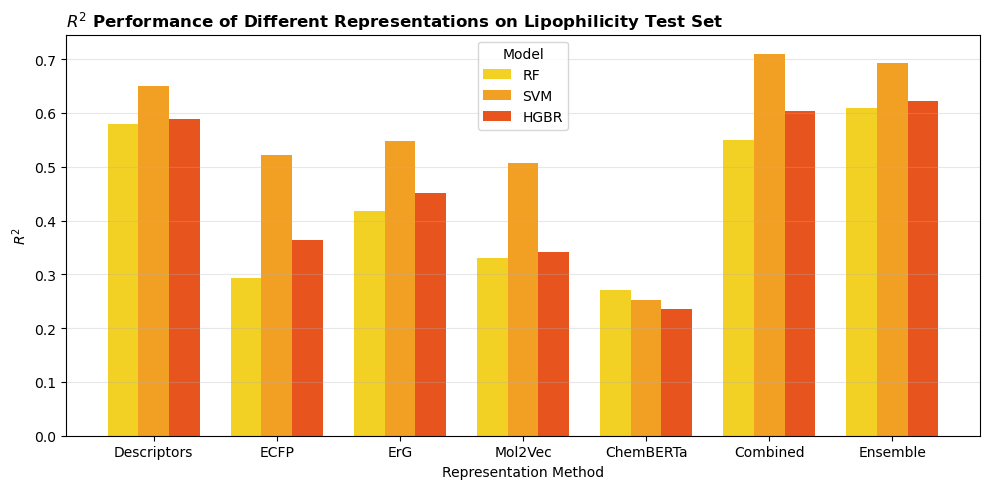

In [159]:
import matplotlib.pyplot as plt
import numpy as np

def plot_r2_comparison(representations, rf_r2, svm_r2, hgbr_r2, title):
    x = np.arange(len(representations))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, rf_r2, width, label='RF', color='#F2D024')
    ax.bar(x, svm_r2, width, label='SVM', color='#F2A024')
    ax.bar(x + width, hgbr_r2, width, label='HGBR', color='#E8541E')

    ax.set_xlabel('Representation Method')
    ax.set_ylabel('$R^2$')
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(representations)
    ax.legend(title='Model')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_r2_comparison(
    representations=['Descriptors', 'ECFP', 'ErG', 'Mol2Vec', 'ChemBERTa', 'Combined', 'Ensemble'],
    rf_r2=[0.579, 0.294, 0.417, 0.331, 0.270, 0.550, 0.610],
    svm_r2=[0.650, 0.521, 0.547, 0.506, 0.253, 0.710, 0.692],
    hgbr_r2=[0.589, 0.363, 0.451, 0.341, 0.236, 0.604, 0.622],
    title='$R^2$ Performance of Different Representations on Lipophilicity Test Set'
)